# AMI — Combining Annual Reports + Job Postings

Compares the two evidence tracks (annual-report NLP scores and job-posting signal scores)
at **company** and **tier** levels, and analyzes **annual-report progression over time**.

**Design decisions (locked):**
- Annual reports represented by **the aggregated 3 years of reports** per company for the combine.
- Postings metric: **total signal density** (per-posting mean); Agentic-only density 
- Each source **z-scored within itself** so they're comparable.
- Levels: **company** and **tier**. (Region dropped — group-level reports have no regional split.)
- Progression: **all companies, gaps flagged**.

**Important caveats baked into the reading of results:**
- Small n (~29) → correlations are **exploratory, not confirmatory**.
- Role-evolution appears in both sources, so any correlation there is partly mechanical.
- Postings are a current snapshot; reports aggregate the available fiscal years — different time bases.

### 0. Setup

In [2]:
import sys
for pkg in ["pandas","numpy","matplotlib","seaborn","scipy"]:
    try: __import__(pkg); print(f"  {pkg:12s} OK")
    except ImportError: print(f"  {pkg:12s} MISSING")


  pandas       OK
  numpy        OK
  matplotlib   OK
  seaborn      OK
  scipy        OK


In [3]:
%pip install pandas numpy matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import json

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"]=110; plt.rcParams["savefig.dpi"]=150
plt.rcParams["savefig.bbox"]="tight"; plt.rcParams["axes.titleweight"]="bold"
TIER_COLORS={"A": "#4d7298", "B": "#66ad76", "C": "#de73aa"}

#  paths: resolved relative to the repo, not to any one machine 
def _find_repo_root():
    """Walk up from the working directory until the repo layout is found."""
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "data").is_dir() and (cand / "notebooks").is_dir():
            return cand
    return here

ROOT = _find_repo_root()
DATA = ROOT / "data"
FIG_DIR = ROOT / "figures" / "ami_ml_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")
    print(f"  saved -> {FIG_DIR.name}/{name}.png")

AR_PATH       = DATA / "ami_results_wide.csv"
POST_PATH     = DATA / "posting_level_detail.csv"
PHRASE_DETAIL = DATA / "phrase_detail.csv"

_missing = [p.name for p in (AR_PATH, POST_PATH, PHRASE_DETAIL) if not p.exists()]
if _missing:
    raise FileNotFoundError(
        f"Missing from {DATA}: {_missing}\n"
        "These are produced by notebooks 01 and 02; copies are provided in data/. "
        "See data/README.md."
    )

def zscore(s): return (s-s.mean())/s.std(ddof=0) if s.std(ddof=0) else s*0

print(f"Repo root: {ROOT}")
print(f"Figures ->  {FIG_DIR}")
print("Setup done.")


Repo root: /Users/savannahwand/Library/CloudStorage/OneDrive-Personal/Documents/Bayes Term 3/GRP/github
Figures ->  /Users/savannahwand/Library/CloudStorage/OneDrive-Personal/Documents/Bayes Term 3/GRP/github/figures/ami_ml_figures
Setup done.


### 1. Load both sources & check the join key

In [5]:
ar = pd.read_csv(AR_PATH)
p  = pd.read_csv(POST_PATH)
print(f"Reports: {ar.shape}, {ar['company'].nunique()} companies, years {sorted(ar['year'].unique())}")
print(f"Postings: {p.shape}, {p['company'].nunique()} companies")

ar_co, p_co = set(ar['company'].unique()), set(p['company'].astype(str).unique())
both = sorted(ar_co & p_co)
print(f"\nIn BOTH ({len(both)}): {both}")
print(f"Only in reports: {sorted(ar_co - p_co)}")
print(f"Only in postings: {sorted(p_co - ar_co)}")
print("\n-> Combined analysis runs on the companies in BOTH.")


Reports: (86, 21), 29 companies, years [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Postings: (2984, 8), 29 companies

In BOTH (29): ['AXA', 'Admiral', 'Ageas', 'Allianz', 'Alm Brand Group', 'Aviva', 'Beazley', 'Bolttech', 'Coface', 'Generali', 'Gjensidige', 'Helvetia Baloise', 'Hiscox', 'Lemonade', 'Linea Directa Aseguradora', 'Mapfre', 'Marshmallow', 'Munich Re', 'NN Group', 'Neodigital', 'Sampo', 'Swiss Re', 'Talanx', 'Tryg', 'Unipol', 'VIG', 'Wakam', 'Zego', 'Zurich']
Only in reports: []
Only in postings: []

-> Combined analysis runs on the companies in BOTH.


### 2. Collapse each source to one value per company

In [6]:
# POSTINGS: total signal density (mean signals per posting) + volume
post = p.groupby("company").agg(
    n_postings=("signal_count","size"),
    post_density_total=("signal_count","mean"),
).reset_index()
post["post_density_total"] = post["post_density_total"].round(3)

# REPORTS: aggregate across ALL available years per company (sum raw hits, then take the
# ratio) -- NOT latest-year-only, and NOT an average of yearly ratios, since that would
# over-weight years with tiny/zero denominators (e.g. a company with 0/1 hits one year
# would count equally alongside a year with 20/40 hits under a naive average). Matches the
# locked methodology in ami_combine_analysis_scoring.ipynb -- kept in sync with that notebook.
ar_agg = ar.groupby("company", as_index=False).agg(
    tier=("tier","first"),
    n_years=("year","nunique"),
    years_used=("year", lambda s: sorted(s.unique().tolist())),
    tokens_total=("tokens","sum"),
    raw_agentic=("raw_agentic","sum"),
    raw_prior_gen_automation=("raw_prior_gen_automation","sum"),
)
ar_agg["total_automation_hits"] = ar_agg["raw_agentic"] + ar_agg["raw_prior_gen_automation"]
ar_agg["agentic_share_of_automation"] = (
    ar_agg["raw_agentic"] / ar_agg["total_automation_hits"].replace(0, np.nan)
).fillna(0)  # true 0/0 (no automation-dimension language detected at all) stays 0, not NaN

# the 3 per-10k dimension rates aren't raw counts in this file, so aggregate them as a
# token-weighted average across years (mathematically equal to summing the underlying
# raw hits and dividing by summed tokens, since rate_i = raw_i / tokens_i * 10000)
def token_weighted_mean(df_year, col):
    w = df_year["tokens"]
    return (df_year[col] * w).sum() / w.sum() if w.sum() else 0.0

dim_agg = ar.groupby("company").apply(
    lambda g: pd.Series({
        "dim_role_evolution_per10k": token_weighted_mean(g, "dim_role_evolution_per10k"),
        "dim_tech_stack_per10k":     token_weighted_mean(g, "dim_tech_stack_per10k"),
        "dim_governance_per10k":     token_weighted_mean(g, "dim_governance_per10k"),
    })
).reset_index()

ar_agg = ar_agg.merge(dim_agg, on="company", how="left")

ar_agg["rep_composite"] = (
    zscore(ar_agg["dim_role_evolution_per10k"])
  + zscore(ar_agg["dim_tech_stack_per10k"])
  + zscore(ar_agg["dim_governance_per10k"])
) / 3

rep_cols = ["company","tier","n_years","years_used","total_automation_hits",
            "agentic_share_of_automation","dim_role_evolution_per10k",
            "dim_tech_stack_per10k","dim_governance_per10k","rep_composite"]
rep = ar_agg[rep_cols].copy()
print("Reports (3-year aggregate) sample:")
print(rep.head().round(3).to_string(index=False))
print(f"\nCompanies with <3 years of report coverage (interpret cautiously): "
      f"{rep[rep['n_years']<3]['company'].tolist()}")


Reports (3-year aggregate) sample:
        company tier  n_years         years_used  total_automation_hits  agentic_share_of_automation  dim_role_evolution_per10k  dim_tech_stack_per10k  dim_governance_per10k  rep_composite
            AXA    A        3 [2023, 2024, 2025]                    175                        0.720                      2.589                  2.737                  3.728          0.875
        Admiral    B        3 [2023, 2024, 2025]                     78                        0.846                      1.283                  1.969                  1.601         -0.281
          Ageas    B        3 [2023, 2024, 2025]                    154                        0.662                      1.619                  2.638                  3.000          0.345
        Allianz    A        3 [2023, 2024, 2025]                     49                        0.755                      1.196                  4.888                  2.691          0.400
Alm Brand Group    C

### 3. Merge + standardize (the combined table)

In [7]:
m = rep.merge(post, on="company", how="inner")

# standardize within each source
m["z_report_share"]  = zscore(m["agentic_share_of_automation"])
m["z_report_comp"]   = zscore(m["rep_composite"])
m["z_postings_total"]= zscore(m["post_density_total"])

m = m.sort_values("z_report_share", ascending=False).reset_index(drop=True)
m.to_csv(FIG_DIR/"combined_company_scores.csv", index=False)
print(f"Combined table: {len(m)} companies")
m[["company","tier","agentic_share_of_automation","post_density_total",
   "z_report_share","z_postings_total","n_postings"]].round(2)


Combined table: 29 companies


,company,tier,agentic_share_of_automation,post_density_total,z_report_share,z_postings_total,n_postings
0,Zego,C,1.00,14.84,1.37,2.48,32
1,Marshmallow,C,1.00,10.15,1.37,1.26,13
2,Aviva,A,0.90,1.80,1.04,-0.90,25
3,Munich Re,A,0.90,3.88,1.04,-0.36,8
4,Zurich,A,0.86,2.88,0.91,-0.62,56
5,Admiral,B,0.85,7.29,0.86,0.52,31
6,Talanx,A,0.82,1.90,0.77,-0.87,160
7,Lemonade,C,0.80,10.00,0.71,1.22,4
8,Mapfre,A,0.79,2.22,0.66,-0.79,40
9,NN Group,A,0.77,10.14,0.62,1.26,62


In [8]:
m["divergence"] = (m["z_report_share"] - m["z_postings_total"]) / np.sqrt(2)

### 3b. Agentic-only postings density

In [9]:
pd_det = pd.read_csv(PHRASE_DETAIL)

agentic = pd_det[pd_det["category"] == "agentic"].groupby("company")["count"].sum()
totals = p.groupby("company").size()

agentic_density = (agentic / totals).fillna(0).reset_index()
agentic_density.columns = ["company", "post_density_agentic"]

m = m.drop(columns=[c for c in ["post_density_agentic","z_postings_agentic"] if c in m.columns])

m = m.merge(agentic_density, on="company", how="left")
m["post_density_agentic"] = m["post_density_agentic"].fillna(0)
m["z_postings_agentic"] = zscore(m["post_density_agentic"])
print(f"Agentic-only density added for {len(m)} companies.")
print(m[["company", "post_density_total", "post_density_agentic",
         "z_postings_agentic"]].round(3).sort_values("post_density_agentic", ascending=False).to_string(index=False))

Agentic-only density added for 29 companies.
                  company  post_density_total  post_density_agentic  z_postings_agentic
                    Wakam              14.846                 3.231               3.069
Linea Directa Aseguradora               5.200                 2.800               2.550
               Gjensidige               7.235                 2.118               1.727
              Marshmallow              10.154                 1.769               1.307
                 NN Group              10.145                 1.274               0.710
                     Zego              14.844                 1.188               0.605
                 Generali               5.959                 1.045               0.433
                    Ageas               7.071                 0.857               0.207
                  Allianz               5.312                 0.769               0.101
                 Swiss Re               9.326                 0.732        

### 4. Company-level comparison — do the two sources agree?

  saved -> ami_ml_figures/01_report_vs_postings_scatter.png


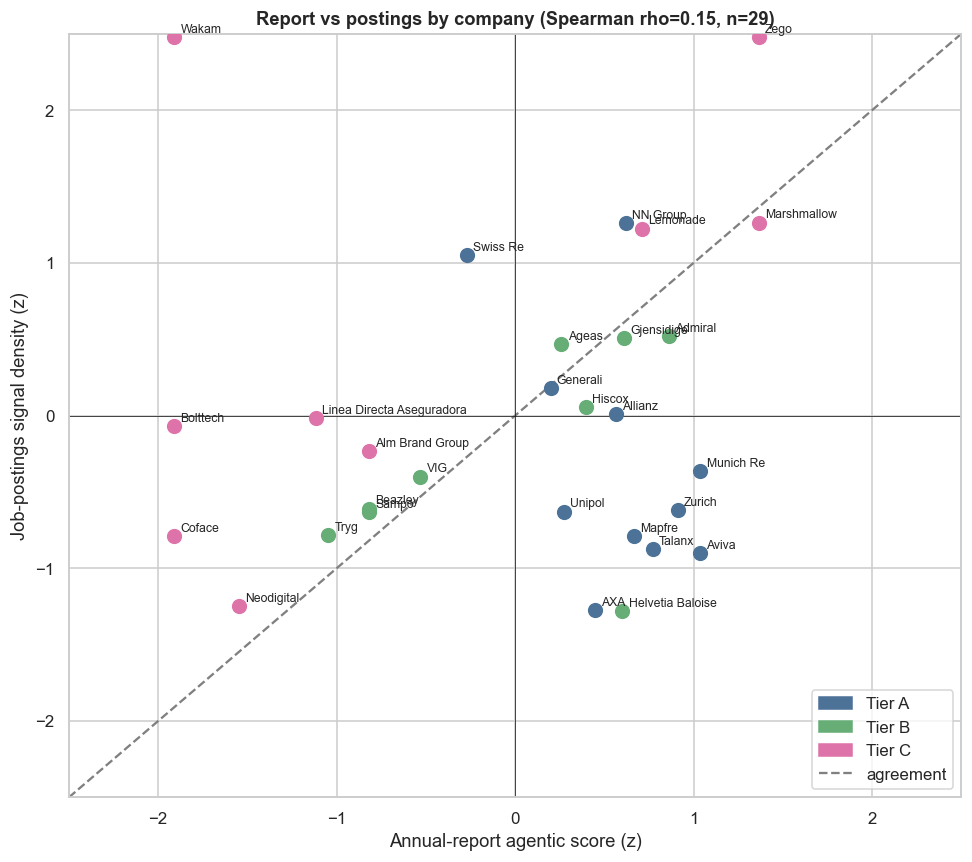

Off-diagonal = the two sources disagree for that company.
Upper-left: strong on postings, weak in report. Lower-right: strong in report, weak on postings.


In [10]:
from scipy.stats import spearmanr
rho, pval = spearmanr(m["z_report_share"], m["z_postings_total"])
# scatter: report-z (x) vs postings-z (y), diagonal = perfect agreement
fig, ax = plt.subplots(figsize=(9,8))
for _,r in m.iterrows():
    ax.scatter(r["z_report_share"], r["z_postings_total"], s=80,
               color=TIER_COLORS.get(r["tier"],"#888"), zorder=3)
    ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]),
                fontsize=8, xytext=(4,3), textcoords="offset points")
lim=2.5
ax.plot([-lim,lim],[-lim,lim],"--",color="gray",label="agreement (y=x)")
ax.axhline(0,color="k",lw=0.5); ax.axvline(0,color="k",lw=0.5)
ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim)
ax.set_xlabel("Annual-report agentic score (z)")
ax.set_ylabel("Job-postings signal density (z)")
ax.set_title(f"Report vs postings by company (Spearman rho={rho:.2f}, n={len(m)})")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c,label=f"Tier {t}") for t,c in TIER_COLORS.items()]
          +[plt.Line2D([],[],ls="--",color="gray",label="agreement")],loc="lower right")
plt.tight_layout(); save(fig,"01_report_vs_postings_scatter"); plt.show()

print("Off-diagonal = the two sources disagree for that company.")
print("Upper-left: strong on postings, weak in report. Lower-right: strong in report, weak on postings.")


### 10. Final AMI Score — Combining the Two Tracks (Three Methods Compared)

Group decision: **simple averaging of the report-z and postings-z scores is off the table** — the two
tracks measure genuinely different things (what a firm *says* vs. what it *hires for*), and a plain
average would let a firm's talk quietly cancel out weak hiring (or vice versa).

Three alternative approaches are built below, each producing a company-level **0–100 AMI score** and
a **Phase 1 (Assisted) / Phase 2 (Augmented) / Phase 3 (Frontier)** bucket, using equal thirds of the
0–100 range as the default cut points (33.3 / 66.7 — tunable, same spirit as the dimension-weight
sensitivity checks elsewhere in this notebook):

- **10a. Cell-based** — bins each company into a 4x4 report x postings grid and looks up a score from
  an explicit, hand-inspectable matrix. Most transparent for a non-technical audience.
- **10b. Bottleneck** — score is driven by the *weaker* of the two tracks. Harshest: a firm can't buy a
  high score with talk alone, or with hiring alone.
- **10c. Distance-from-origin (penalized)** — rewards total distance from an "average firm" in the
  positive direction, then subtracts a penalty for how unbalanced the two tracks are. Continuous and
  tunable via a single lambda parameter.

All three are shown side by side in **10d** so the group/Sabine can compare before picking one (or
justifying a blend) for the write-up.

In [11]:
# ---- shared helpers for all 3 scoring methods ----
PHASE_ORDER  = ["Phase 1 - Assisted", "Phase 2 - Augmented", "Phase 3 - Frontier"]
PHASE_COLORS = {"Phase 1 - Assisted": "#67839c",
                 "Phase 2 - Augmented": "#739480",
                 "Phase 3 - Frontier": "#cc9dc2"}

def minmax_100(s):
    """Rescale a numeric series to 0-100 across the sample (same convention as the AMI dimensions)."""
    lo, hi = s.min(), s.max()
    return ((s - lo) / (hi - lo) * 100) if hi > lo else pd.Series(50.0, index=s.index)

def phase_from_score(score):
    if score < 33.34:  return "Phase 1 - Assisted"
    elif score < 66.67: return "Phase 2 - Augmented"
    return "Phase 3 - Frontier"

def qbin(s, n=4):
    """Rank-based quantile binning -> robust to the tied/floor z-scores in this dataset
    (several companies share the same zero-signal floor, which breaks a plain qcut)."""
    return pd.qcut(s.rank(method="first"), n, labels=False)

print("Helpers ready.")

Helpers ready.


#### 10a. Cell-based (4x4 matrix lookup)

Each company is binned into a quartile (Low / Med-Low / Med-High / High) on each track, giving a
4x4 = 16-cell grid. Each cell has an explicit score, built as *(average of the two bin positions)*,
**penalized by how far apart the two bins are** — so a company that's High/High scores 100, but a
company that's High/Low (all talk, or all hiring, no alignment) scores well below a company that's
Med-High/Med-High, even though their raw bin totals could otherwise tie. `GAP_PENALTY` is the tunable
knob (points deducted per bin of mismatch).

In [12]:
GAP_PENALTY = 12  # points deducted per bin of mismatch between the two tracks -- tune & sensitivity-check

def cell_score(rep_bin, post_bin, penalty=GAP_PENALTY):
    base = (rep_bin + post_bin) / 6 * 100          # 0-100 from the average bin position
    gap  = abs(rep_bin - post_bin)                  # 0-3: how mismatched the two tracks are
    return max(0.0, base - penalty * gap)

m["report_bin"]   = qbin(m["z_report_share"])
m["postings_bin"] = qbin(m["z_postings_total"])
m["score_cell"]   = m.apply(lambda r: cell_score(r["report_bin"], r["postings_bin"]), axis=1)
m["phase_cell"]   = m["score_cell"].apply(phase_from_score)

cell_table = pd.DataFrame({pb: [cell_score(rb, pb) for rb in range(4)] for pb in range(4)}, index=range(4))
cell_table.index.name = "report_bin"; cell_table.columns.name = "postings_bin"
print("Cell lookup table (rows=report bin, cols=postings bin):")
print(cell_table.round(1).to_string())
print()
print(m[["company","tier","report_bin","postings_bin","score_cell","phase_cell"]]
      .sort_values("score_cell", ascending=False).round(1).to_string(index=False))

Cell lookup table (rows=report bin, cols=postings bin):
postings_bin     0     1     2      3
report_bin                           
0              0.0   4.7   9.3   14.0
1              4.7  33.3  38.0   42.7
2              9.3  38.0  66.7   71.3
3             14.0  42.7  71.3  100.0

                  company tier  report_bin  postings_bin  score_cell          phase_cell
                     Zego    C           3             3       100.0  Phase 3 - Frontier
                  Admiral    B           3             3       100.0  Phase 3 - Frontier
              Marshmallow    C           3             3       100.0  Phase 3 - Frontier
                 Lemonade    C           2             3        71.3  Phase 3 - Frontier
                 NN Group    A           2             3        71.3  Phase 3 - Frontier
                  Allianz    A           2             2        66.7 Phase 2 - Augmented
               Gjensidige    B           2             2        66.7 Phase 2 - Augmented
   

#### 10b. Bottleneck (weaker track wins)

`score = min(z_report_share, z_postings_total)`, rescaled to 0-100. A company only scores well if
**both** tracks are strong — there's no way to compensate a weak track with a strong one. This is the
most conservative of the three methods.

In [13]:
m["bottleneck_z"]      = m[["z_report_share", "z_postings_total"]].min(axis=1)
m["score_bottleneck"]  = minmax_100(m["bottleneck_z"])
m["phase_bottleneck"]  = m["score_bottleneck"].apply(phase_from_score)

print(m[["company","tier","z_report_share","z_postings_total","score_bottleneck","phase_bottleneck"]]
      .sort_values("score_bottleneck", ascending=False).round(1).to_string(index=False))

                  company tier  z_report_share  z_postings_total  score_bottleneck    phase_bottleneck
                     Zego    C             1.4               2.5             100.0  Phase 3 - Frontier
              Marshmallow    C             1.4               1.3              96.9  Phase 3 - Frontier
                 Lemonade    C             0.7               1.2              80.0  Phase 3 - Frontier
                 NN Group    A             0.6               1.3              77.2  Phase 3 - Frontier
                  Admiral    B             0.9               0.5              74.3  Phase 3 - Frontier
               Gjensidige    B             0.6               0.5              73.8  Phase 3 - Frontier
                    Ageas    B             0.3               0.5              66.2 Phase 2 - Augmented
                 Generali    A             0.2               0.2              63.8 Phase 2 - Augmented
                   Hiscox    B             0.4               0.1         

#### 10c. Distance-from-origin (penalized for imbalance)

**Note on the method:** raw Euclidean distance from the origin (`sqrt(x^2 + y^2)`) turns out not to
work directly for a maturity score — it's direction-agnostic, so a company that's far *below* average
on both tracks gets the same high distance as a company far *above* average on both (tested this on a
synthetic check before building it in; a company weak on both tracks was landing in Phase 3, which
isn't right). The fix is a **signed** version: project onto the positive "aligned & high" diagonal
(`(x + y) / sqrt(2)`) rather than taking the unsigned magnitude, then subtract the same
imbalance penalty as before. This keeps the "reward total strength, penalize the gap" logic while
making sure direction is respected.

In [14]:
LAMBDA = 0.5  # points deducted per unit of imbalance -- tunable, sensitivity-check like the other knobs

m["gap"]               = (m["z_report_share"] - m["z_postings_total"]).abs()
m["signed_distance"]   = (m["z_report_share"] + m["z_postings_total"]) / np.sqrt(2)
m["adjusted_distance"] = m["signed_distance"] - LAMBDA * m["gap"]
m["score_distance"]    = minmax_100(m["adjusted_distance"])
m["phase_distance"]    = m["score_distance"].apply(phase_from_score)

print(m[["company","tier","z_report_share","z_postings_total","gap","score_distance","phase_distance"]]
      .sort_values("score_distance", ascending=False).round(2).to_string(index=False))

                  company tier  z_report_share  z_postings_total  gap  score_distance      phase_distance
                     Zego    C            1.37              2.48 1.11          100.00  Phase 3 - Frontier
              Marshmallow    C            1.37              1.26 0.10           92.38  Phase 3 - Frontier
                 Lemonade    C            0.71              1.22 0.51           77.31  Phase 3 - Frontier
                 NN Group    A            0.62              1.26 0.64           75.10  Phase 3 - Frontier
                  Admiral    B            0.86              0.52 0.34           70.80  Phase 3 - Frontier
               Gjensidige    B            0.61              0.51 0.10           69.30  Phase 3 - Frontier
                    Ageas    B            0.26              0.47 0.21           62.17 Phase 2 - Augmented
                 Generali    A            0.20              0.18 0.02           58.85 Phase 2 - Augmented
                   Hiscox    B            0.40

In [15]:
m["score_bottleneck"] = ((np.minimum(m.z_report_share, m.z_postings_total) - 
                          np.minimum(m.z_report_share, m.z_postings_total).min()) /
                         np.ptp(np.minimum(m.z_report_share, m.z_postings_total)) * 100)

proj = (m.z_report_share + m.z_postings_total) / np.sqrt(2)
pen  = 0.5 * (m.z_report_share - m.z_postings_total).abs()
raw  = proj - pen
m["score_distance"] = (raw - raw.min()) / np.ptp(raw) * 100

methods = ["score_cell", "score_bottleneck", "score_distance"]
print("Spearman rank correlation between the three methods:")
print(m[methods].corr(method="spearman").round(3).to_string())
print("\nPhase agreement vs cell-based:")
for meth in methods[1:]:
    agree = (m[meth].apply(phase_from_score) == m["score_cell"].apply(phase_from_score)).sum()
    print(f"  {meth:18} {agree}/{len(m)} companies in same phase")

Spearman rank correlation between the three methods:
                  score_cell  score_bottleneck  score_distance
score_cell             1.000             0.882           0.917
score_bottleneck       0.882             1.000           0.986
score_distance         0.917             0.986           1.000

Phase agreement vs cell-based:
  score_bottleneck   25/29 companies in same phase
  score_distance     23/29 companies in same phase


### 11. Clustering — does an unsupervised method recover the archetypes?

Per the academic advisor's suggestion: rather than manually averaging or combining the two tracks,
test whether an unsupervised method finds the same structure on its own. Using the **2 composite
z-scores** (`z_report_share`, `z_postings_total`) — the same two axes the manual quadrant is built
on — so this is a direct, apples-to-apples test of whether clustering recovers the 4 archetypes
(Aligned leaders / Talkers / Quiet builders / Laggards), rather than a richer feature set that
wouldn't be directly comparable.

Both z-scores are already standardized (mean 0, std 1), so no additional scaling is needed before
clustering.

Two algorithms, so we're not relying on one method's quirks:
- **K-means** — needs k specified up front; we check k via an elbow/silhouette diagnostic first.
- **Hierarchical (Ward linkage)** — no k needed to *fit*, but we still cut the tree at k=4 for
  comparison; the dendrogram itself is useful to inspect regardless of k.

Agreement with the manual archetypes (and between the two clustering methods) is measured with the
**Adjusted Rand Index** (1 = perfect agreement, 0 = no better than random).

In [16]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

X = m[["z_report_share", "z_postings_total"]].values
CLUSTER_COLORS = ["#41364a", "#5f7d5b", "#cf1549", "#c29b5d", "#7b5ea7", "#3d9aa1", "#d646c5"]
print(f"Feature matrix: {X.shape[0]} companies x {X.shape[1]} features (already z-scored, no rescaling needed).")

Feature matrix: 29 companies x 2 features (already z-scored, no rescaling needed).


#### 11a. Choosing k: elbow + silhouette diagnostic

Before fixing k=4 to match the manual archetypes, check whether the data itself actually supports
4 clusters, or whether it more naturally wants fewer/more. Inertia (elbow) tends to keep dropping
as k increases, so the silhouette score (higher = more separated, well-defined clusters) is the
more informative of the two here.

  saved -> ami_ml_figures/09a_elbow_silhouette.png


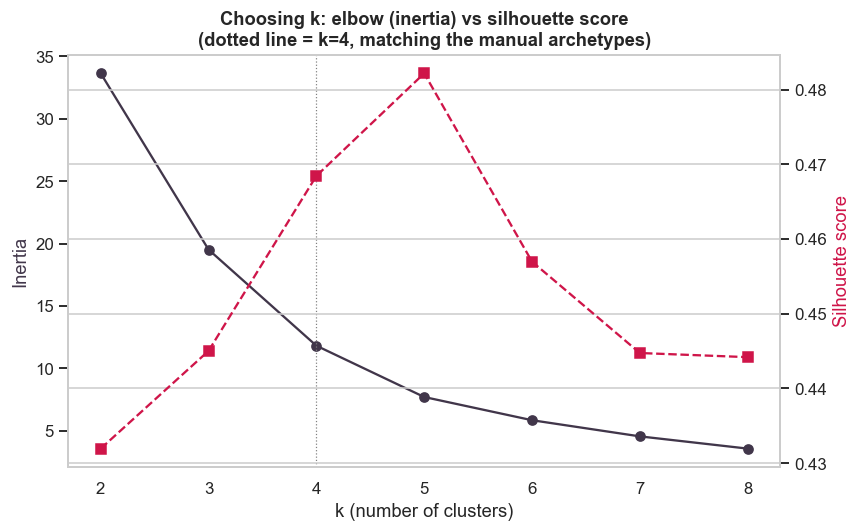

Silhouette scores by k: {2: 0.432, 3: 0.445, 4: 0.468, 5: 0.482, 6: 0.457, 7: 0.445, 8: 0.444}

Best silhouette k: 5  (k=4 used below regardless, for archetype comparability)


In [17]:
ks = range(2, 9)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.grid(False)
ax1.plot(list(ks), inertias, "o-", color="#41364a", label="Inertia (elbow)")
ax1.set_xlabel("k (number of clusters)"); ax1.set_ylabel("Inertia", color="#41364a")
ax2 = ax1.twinx()
ax2.plot(list(ks), sils, "s--", color="#cf1549", label="Silhouette score")
ax2.set_ylabel("Silhouette score", color="#cf1549")
ax1.axvline(4, color="gray", lw=0.8, ls=":")
ax1.set_title("Choosing k: elbow (inertia) vs silhouette score\n(dotted line = k=4, matching the manual archetypes)")
plt.tight_layout(); save(fig, "09a_elbow_silhouette"); plt.show()

print("Silhouette scores by k:", {k: round(s, 3) for k, s in zip(ks, sils)})
print(f"\nBest silhouette k: {list(ks)[int(np.argmax(sils))]}  (k=4 used below regardless, for archetype comparability)")

#### 11b. Graphing Various K-means

  saved -> ami_ml_figures/09b_kmeans4.png


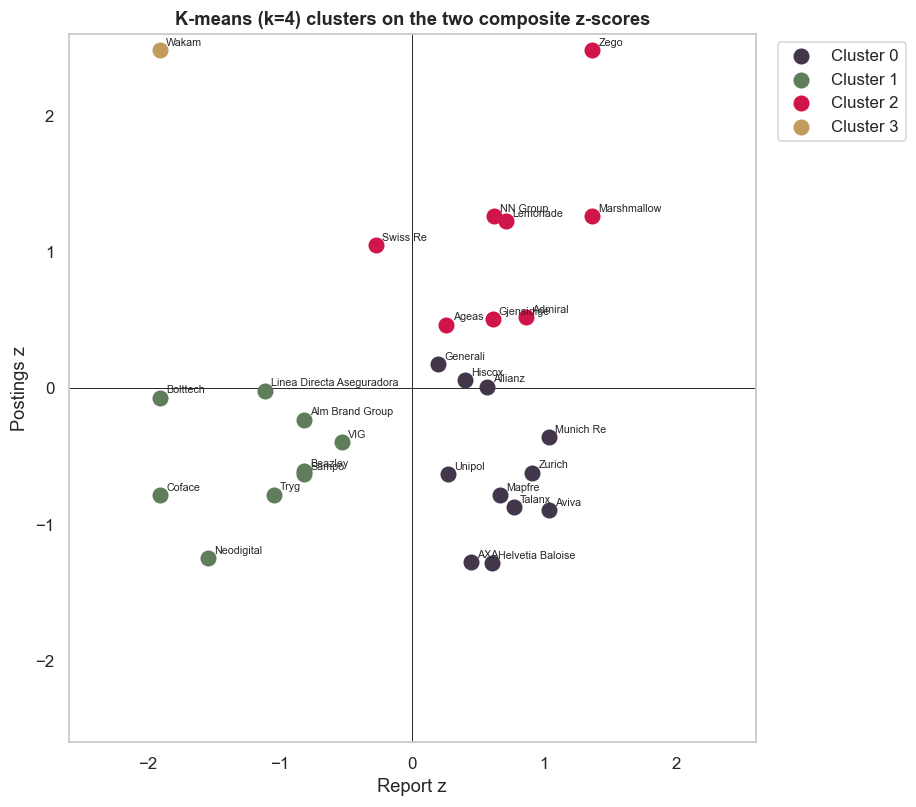

In [18]:
km4 = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X)
m["cluster_kmeans_k4"] = km4.labels_

fig, ax = plt.subplots(figsize=(8.5, 7.5))
ax.grid(False)
for cl in sorted(m["cluster_kmeans_k4"].unique()):
    d = m[m["cluster_kmeans_k4"] == cl]
    ax.scatter(d["z_report_share"], d["z_postings_total"], s=90, color=CLUSTER_COLORS[cl], label=f"Cluster {cl}", zorder=3)
for _, r in m.iterrows():
    ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]), fontsize=7,
                xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
lim = 2.6; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("Report z"); ax.set_ylabel("Postings z")
ax.set_title("K-means (k=4) clusters on the two composite z-scores")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); save(fig, "09b_kmeans4"); plt.show()

  saved -> ami_ml_figures/09b_kmeans5.png


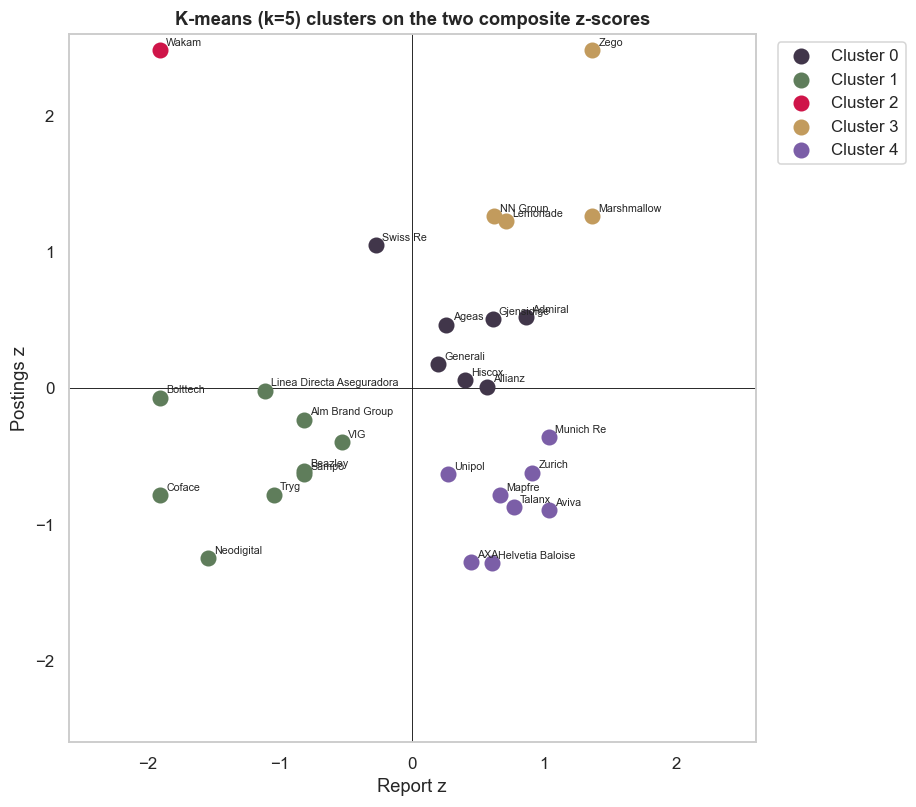

In [19]:
km5 = KMeans(n_clusters=5, n_init=10, random_state=42).fit(X)
m["_tmp_cluster_k5"] = km5.labels_

fig, ax = plt.subplots(figsize=(8.5, 7.5))
ax.grid(False)
for cl in sorted(m["_tmp_cluster_k5"].unique()):
    d = m[m["_tmp_cluster_k5"] == cl]
    ax.scatter(d["z_report_share"], d["z_postings_total"], s=90, color=CLUSTER_COLORS[cl], label=f"Cluster {cl}", zorder=3)
for _, r in m.iterrows():
    ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]), fontsize=7,
                xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
lim = 2.6; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("Report z"); ax.set_ylabel("Postings z")
ax.set_title("K-means (k=5) clusters on the two composite z-scores")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); save(fig, "09b_kmeans5"); plt.show()

  saved -> ami_ml_figures/09b_kmeans6.png


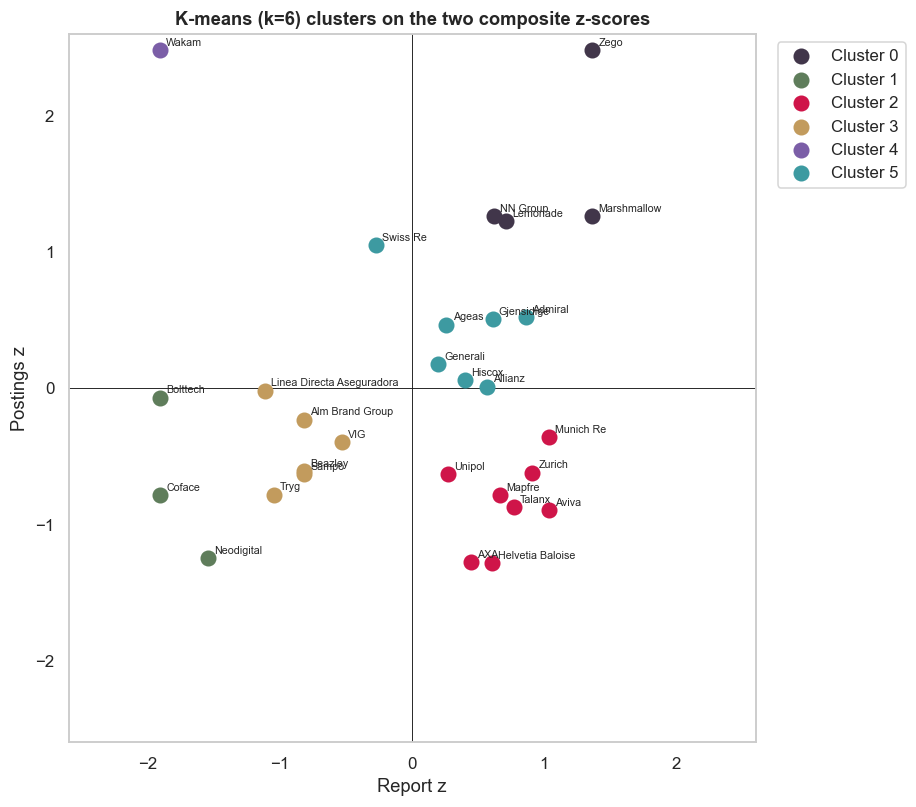

In [20]:
km6 = KMeans(n_clusters=6, n_init=10, random_state=42).fit(X)
m["_tmp_cluster_k6"] = km6.labels_

fig, ax = plt.subplots(figsize=(8.5, 7.5))
ax.grid(False)
for cl in sorted(m["_tmp_cluster_k6"].unique()):
    d = m[m["_tmp_cluster_k6"] == cl]
    ax.scatter(d["z_report_share"], d["z_postings_total"], s=90, color=CLUSTER_COLORS[cl], label=f"Cluster {cl}", zorder=3)
for _, r in m.iterrows():
    ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]), fontsize=7,
                xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
lim = 2.6; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("Report z"); ax.set_ylabel("Postings z")
ax.set_title("K-means (k=6) clusters on the two composite z-scores")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); save(fig, "09b_kmeans6"); plt.show()

  saved -> ami_ml_figures/09b_kmeans7.png


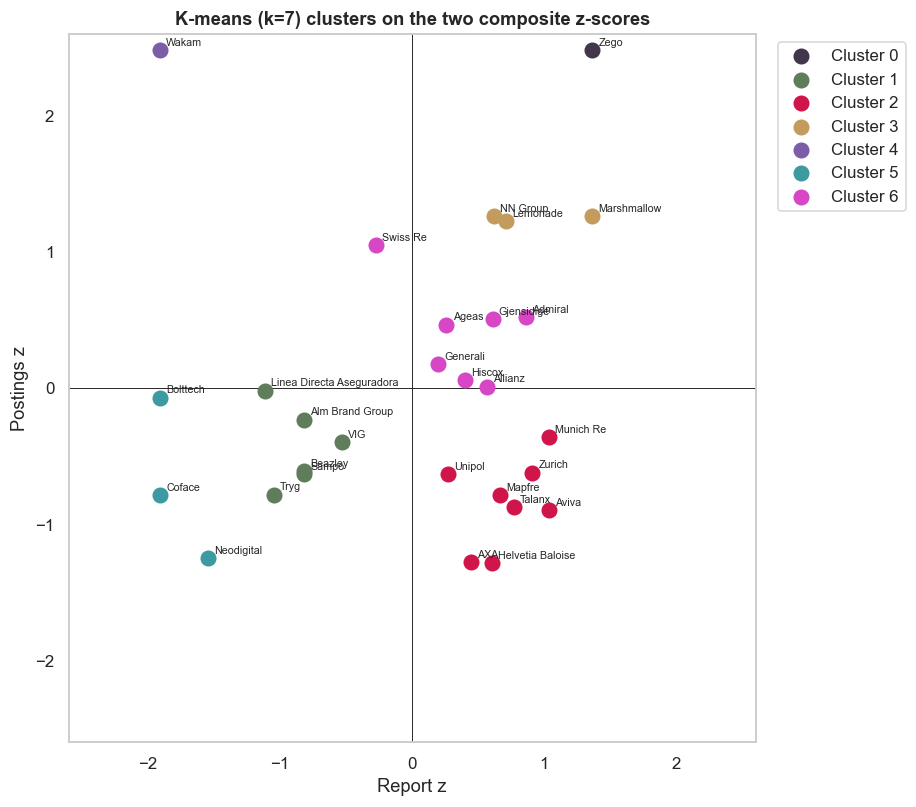

In [21]:
km7 = KMeans(n_clusters=7, n_init=10, random_state=42).fit(X)
m["_tmp_cluster_k7"] = km7.labels_

fig, ax = plt.subplots(figsize=(8.5, 7.5))
ax.grid(False)
for cl in sorted(m["_tmp_cluster_k7"].unique()):
    d = m[m["_tmp_cluster_k7"] == cl]
    ax.scatter(d["z_report_share"], d["z_postings_total"], s=90, color=CLUSTER_COLORS[cl], label=f"Cluster {cl}", zorder=3)
for _, r in m.iterrows():
    ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]), fontsize=7,
                xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
lim = 2.6; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("Report z"); ax.set_ylabel("Postings z")
ax.set_title("K-means (k=7) clusters on the two composite z-scores")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); save(fig, "09b_kmeans7"); plt.show()

##### **11b. Interpretation**

Silhouette scores: 0.71–1.0 = strong structure, 0.51–0.70 = reasonable structure, 0.26–0.50 = weak; (Kaufman & Rousseeuw)

With the best score (k=5) being 0.482, none of the k values tested reach a silhouette score that would count as genuinely well-separated clustering. 
The scores are also fairly flat across k=5–8 rather than peaking sharply, which is a second sign that the data isn't telling you a clean "natural" number of groups.

Moving from k=5 to k=7 is just supdividing the groups rather than revealing a qualitatively different structure.

#### 11c. Do the clusters agree with the manual archetypes?

Cross-tabs show exactly which companies land where; the Adjusted Rand Index gives a single number
per comparison (1 = perfect agreement, 0 = no better than a random split of the same sizes).

=== ARCHETYPES ===
Aligned leaders    (10): Zego, Marshmallow, Admiral, Lemonade, NN Group, Gjensidige, Allianz, Hiscox, Ageas, Generali
Talkers            (8): Aviva, Munich Re, Zurich, Talanx, Mapfre, Helvetia Baloise, AXA, Unipol
Quiet builders     (2): Swiss Re, Wakam
Laggards           (9): VIG, Beazley, Sampo, Alm Brand Group, Tryg, Linea Directa Aseguradora, Neodigital, Coface, Bolttech
  saved -> ami_ml_figures/07_archetype_quadrants.png


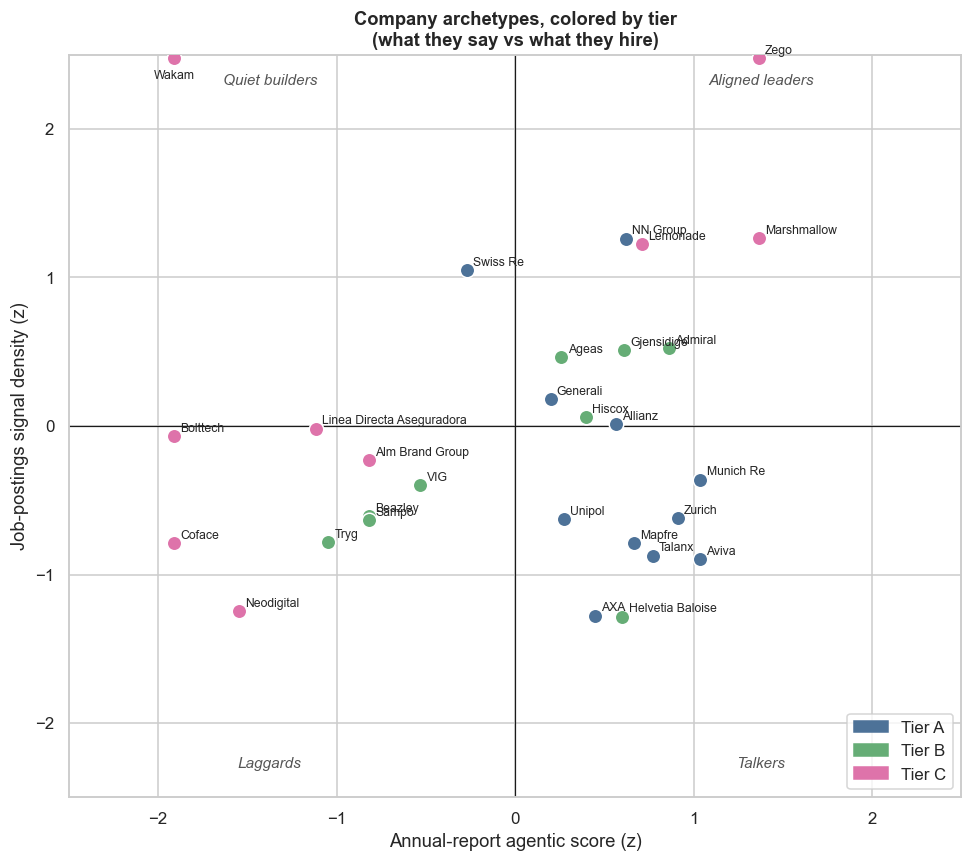

In [22]:
def archetype(row):
    hi_rep = row["z_report_share"] >= 0
    hi_post = row["z_postings_total"] >= 0
    if hi_rep and hi_post:    return "Aligned leaders"
    if hi_rep and not hi_post: return "Talkers"
    if not hi_rep and hi_post: return "Quiet builders"
    return "Laggards"

m["archetype"] = m.apply(archetype, axis=1)
print("=== ARCHETYPES ===")
for a in ["Aligned leaders","Talkers","Quiet builders","Laggards"]:
    names = m[m["archetype"]==a]["company"].tolist()
    print(f"{a:18s} ({len(names)}): {', '.join(names)}")
m[["company","tier","archetype","z_report_share","z_postings_total"]].to_csv(FIG_DIR/"company_archetypes.csv", index=False)

# quadrant scatter — dots colored by TIER, quadrant labels name the archetypes
fig, ax = plt.subplots(figsize=(9, 8))
for _, r in m.iterrows():
    ax.scatter(r["z_report_share"], r["z_postings_total"], s=90,
               color=TIER_COLORS.get(r["tier"], "#888"), zorder=3, edgecolor="white")
    if r["company"] == "Wakam":
        # one-off: label sits directly below the dot
        ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]),
                    fontsize=8, xytext=(0, -8), textcoords="offset points", va="top", ha="center")
    else:
        ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]),
                    fontsize=8, xytext=(4,3), textcoords="offset points")
ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)
lim = 2.5; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

# quadrant labels (grey, in the corners) so archetype + tier are both readable
ax.text(lim*0.55,  lim*0.92, "Aligned leaders", color="#555", fontsize=10, ha="center", style="italic")
ax.text(-lim*0.55, lim*0.92, "Quiet builders", color="#555", fontsize=10, ha="center", style="italic")
ax.text(lim*0.55, -lim*0.92, "Talkers",         color="#555", fontsize=10, ha="center", style="italic")
ax.text(-lim*0.55,-lim*0.92, "Laggards",        color="#555", fontsize=10, ha="center", style="italic")


ax.set_xlabel("Annual-report agentic score (z)")
ax.set_ylabel("Job-postings signal density (z)")
ax.set_title("Company archetypes, colored by tier\n(what they say vs what they hire)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=f"Tier {t}") for t,c in TIER_COLORS.items()], loc="lower right")
plt.tight_layout(); save(fig, "07_archetype_quadrants"); plt.show()

In [23]:
print("=== K-means (k=4) vs manual archetype ===")
print(pd.crosstab(m["archetype"], m["cluster_kmeans_k4"]))

ari_km = adjusted_rand_score(m["archetype"], m["cluster_kmeans_k4"])

print(f"\nAdjusted Rand Index (k-means k=4 vs archetype): {ari_km:.3f}")
print("(1.0 = perfect agreement, 0.0 = no better than random, can go slightly negative)")

m[["company","tier","archetype","z_report_share","z_postings_total","cluster_kmeans_k4"]]\
  .to_csv(FIG_DIR / "clustering_vs_archetypes.csv", index=False)


=== K-means (k=4) vs manual archetype ===
cluster_kmeans_k4  0  1  2  3
archetype                    
Aligned leaders    3  0  7  0
Laggards           0  9  0  0
Quiet builders     0  0  1  1
Talkers            8  0  0  0

Adjusted Rand Index (k-means k=4 vs archetype): 0.678
(1.0 = perfect agreement, 0.0 = no better than random, can go slightly negative)


##### **11c. Interpretation**

K-means (k=4) shows fairly strong agreement with the manual archetypes — ARI = 0.678, well above the 0.0 random baseline. This still leaves room between the unsupervised split and the four-way report/postings archetype split, which supports treating the archetype framework as a deliberate, theory-driven simplification rather than assuming it is exactly what an unsupervised method would produce on its own — but the agreement is closer than earlier drafts suggested.

#### 11d. Exploration Only

**Not used for final index or any score.**

Tests whether Wakam (an extreme outlier) is suppressing k=4 cluster quality. Recomputes z-scores fresh on the remaining 28
companies rather than just dropping Wakam's row from the existing scale, since removing an outlier shifts everyone else's mean/std
too -- same convention as the Section 11 SFCR sensitivity check.

Does not modify `m`.

  k    full (n=29)   excl. Wakam (n=28)
  2          0.432                0.440
  3          0.445                0.485
  4          0.468                0.501
  5          0.482                0.472
  6          0.457                0.450
  7          0.445                0.434
  8          0.444                0.427
  saved -> ami_ml_figures/09e_silhouette_excl_wakam_EXPLORATORY.png


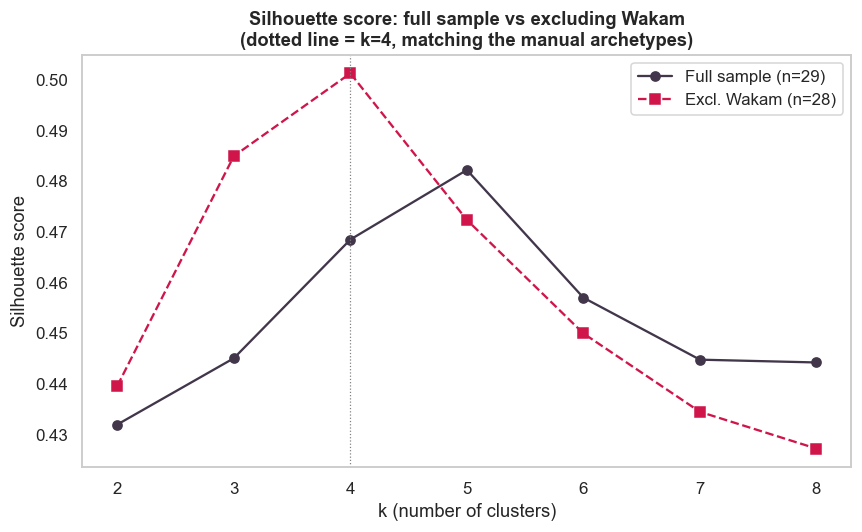


k=4 clusters excluding Wakam:
  Cluster 0: ['Admiral', 'Gjensidige', 'Allianz', 'Hiscox', 'Ageas', 'Generali', 'Swiss Re']
  Cluster 1: ['Aviva', 'Munich Re', 'Zurich', 'Talanx', 'Mapfre', 'Helvetia Baloise', 'AXA', 'Unipol']
  Cluster 2: ['VIG', 'Beazley', 'Sampo', 'Alm Brand Group', 'Tryg', 'Linea Directa Aseguradora', 'Neodigital', 'Coface', 'Bolttech']
  Cluster 3: ['Zego', 'Marshmallow', 'Lemonade', 'NN Group']


In [24]:
m_excl = m[m["company"] != "Wakam"].copy()
m_excl["z_report_share_excl"]   = zscore(m_excl["agentic_share_of_automation"])
m_excl["z_postings_total_excl"] = zscore(m_excl["post_density_total"])
X_excl = m_excl[["z_report_share_excl", "z_postings_total_excl"]].values

sils_full = {k: silhouette_score(X, KMeans(n_clusters=k, n_init=10, random_state=42).fit(X).labels_)
             for k in range(2, 9)}
sils_excl = {k: silhouette_score(X_excl, KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_excl).labels_)
             for k in range(2, 9)}

print(f"{'k':>3} {'full (n=29)':>14} {'excl. Wakam (n=28)':>20}")
for k in range(2, 9):
    print(f"{k:>3} {sils_full[k]:>14.3f} {sils_excl[k]:>20.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(False)
ax.plot(list(sils_full.keys()), list(sils_full.values()), "o-", color="#41364a", label="Full sample (n=29)")
ax.plot(list(sils_excl.keys()), list(sils_excl.values()), "s--", color="#cf1549", label="Excl. Wakam (n=28)")
ax.axvline(4, color="gray", lw=0.8, ls=":")
ax.set_xlabel("k (number of clusters)"); ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette score: full sample vs excluding Wakam\n(dotted line = k=4, matching the manual archetypes)")
ax.legend()
plt.tight_layout(); save(fig, "09e_silhouette_excl_wakam_EXPLORATORY"); plt.show()

# k=4 cluster membership without Wakam, for reference
km4_excl = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_excl)
m_excl["cluster_kmeans_excl"] = km4_excl.labels_
print("\nk=4 clusters excluding Wakam:")
for cl in sorted(m_excl["cluster_kmeans_excl"].unique()):
    print(f"  Cluster {cl}: {m_excl.loc[m_excl['cluster_kmeans_excl']==cl, 'company'].tolist()}")

  saved -> ami_ml_figures/09e_kmeans_excl_wakam_EXPLORATORY.png


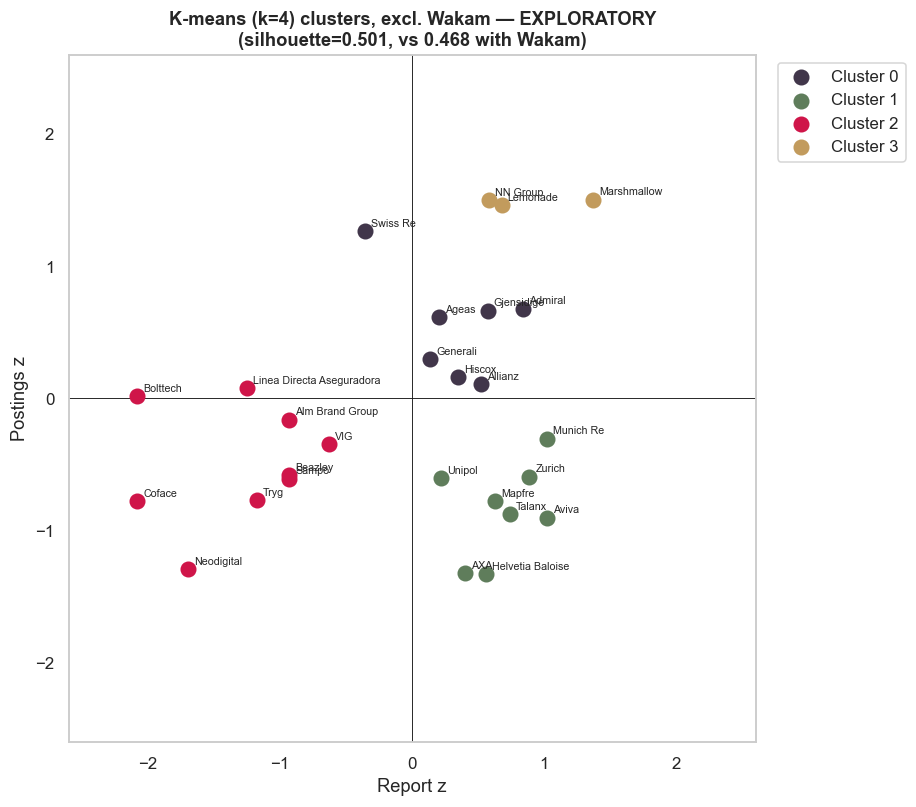

In [25]:
# EXPLORATORY ONLY -- visual companion to the silhouette comparison above. Same k=4, same style as the Section 11 K-means plots, just on the 28-company (excl. Wakam) rescaled data. Does not modify `m`.
fig, ax = plt.subplots(figsize=(8.5, 7.5))
ax.grid(False)
for cl in sorted(m_excl["cluster_kmeans_excl"].unique()):
    d = m_excl[m_excl["cluster_kmeans_excl"] == cl]
    ax.scatter(d["z_report_share_excl"], d["z_postings_total_excl"], s=90,
               color=CLUSTER_COLORS[cl], label=f"Cluster {cl}", zorder=3)
for _, r in m_excl.iterrows():
    ax.annotate(r["company"], (r["z_report_share_excl"], r["z_postings_total_excl"]), fontsize=7,
                xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
lim = 2.6; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)  # same scale as the full-sample plot, for direct comparison
ax.set_xlabel("Report z"); ax.set_ylabel("Postings z")
ax.set_title(f"K-means (k=4) clusters, excl. Wakam — EXPLORATORY\n(silhouette={silhouette_score(X_excl, km4_excl.labels_):.3f}, vs {silhouette_score(X, KMeans(n_clusters=4, n_init=10, random_state=42).fit(X).labels_):.3f} with Wakam)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); save(fig, "09e_kmeans_excl_wakam_EXPLORATORY"); plt.show()

  saved -> ami_ml_figures/09f_kmeans6_excl_wakam_EXPLORATORY.png


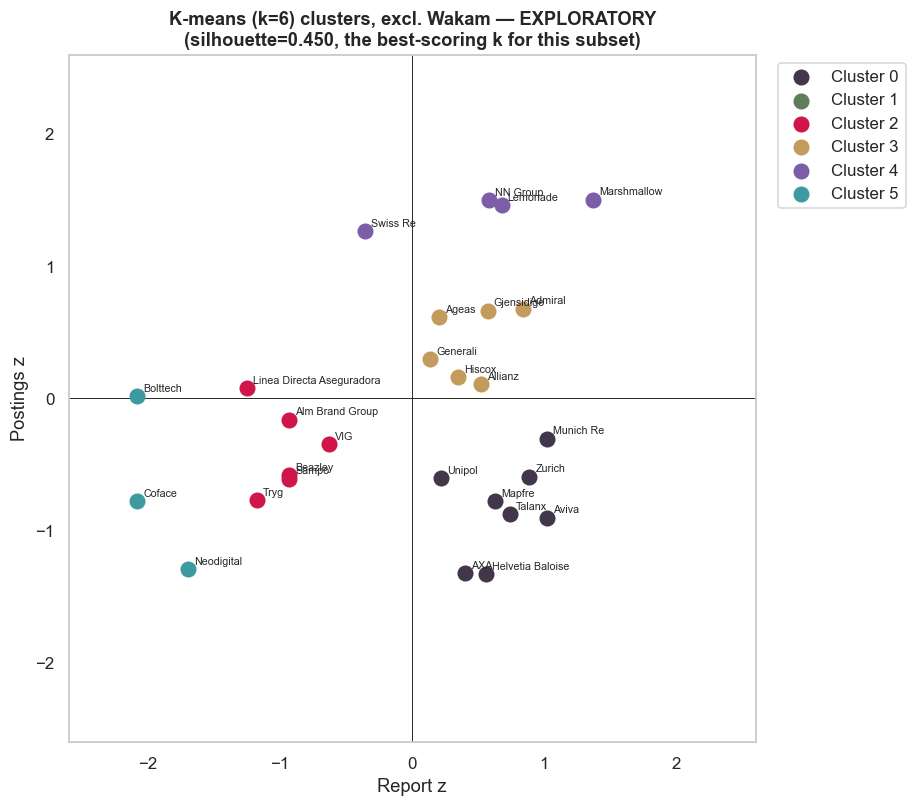

k=6 clusters excluding Wakam:
  Cluster 0: ['Aviva', 'Munich Re', 'Zurich', 'Talanx', 'Mapfre', 'Helvetia Baloise', 'AXA', 'Unipol']
  Cluster 1: ['Zego']
  Cluster 2: ['VIG', 'Beazley', 'Sampo', 'Alm Brand Group', 'Tryg', 'Linea Directa Aseguradora']
  Cluster 3: ['Admiral', 'Gjensidige', 'Allianz', 'Hiscox', 'Ageas', 'Generali']
  Cluster 4: ['Marshmallow', 'Lemonade', 'NN Group', 'Swiss Re']
  Cluster 5: ['Neodigital', 'Coface', 'Bolttech']


In [26]:
# EXPLORATORY ONLY -- k=6 excl. Wakam (silhouette=0.450), shown here for comparison against k=4. Reuses m_excl / X_excl from the previous exploratory cell. Does not modify `m`.
km6_excl = KMeans(n_clusters=6, n_init=10, random_state=42).fit(X_excl)
m_excl["cluster_kmeans_excl_k6"] = km6_excl.labels_

fig, ax = plt.subplots(figsize=(8.5, 7.5))
ax.grid(False)
for cl in sorted(m_excl["cluster_kmeans_excl_k6"].unique()):
    d = m_excl[m_excl["cluster_kmeans_excl_k6"] == cl]
    ax.scatter(d["z_report_share_excl"], d["z_postings_total_excl"], s=90,
               color=CLUSTER_COLORS[cl], label=f"Cluster {cl}", zorder=3)
for _, r in m_excl.iterrows():
    ax.annotate(r["company"], (r["z_report_share_excl"], r["z_postings_total_excl"]), fontsize=7,
                xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
lim = 2.6; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("Report z"); ax.set_ylabel("Postings z")
ax.set_title(f"K-means (k=6) clusters, excl. Wakam — EXPLORATORY\n"
             f"(silhouette={silhouette_score(X_excl, km6_excl.labels_):.3f}, the best-scoring k for this subset)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); save(fig, "09f_kmeans6_excl_wakam_EXPLORATORY"); plt.show()

print("k=6 clusters excluding Wakam:")
for cl in sorted(m_excl["cluster_kmeans_excl_k6"].unique()):
    print(f"  Cluster {cl}: {m_excl.loc[m_excl['cluster_kmeans_excl_k6']==cl, 'company'].tolist()}")

**11d. Interpretation**

Excluding Wakam meaningfully improves k=4 cluster quality: silhouette rises from
0.468 (full sample — "weak" by the Kaufman–Rousseeuw bands) to 0.501 (excl. Wakam
— just short of "reasonable"), and k=4 becomes the best-scoring k for the 28-company
subset, where k=5 was the best on the full sample.

Visually this checks out. In the full-sample k=4 run, Wakam is extreme enough that
k-means effectively spends one of its four clusters isolating it as a singleton (see
the crosstab in 11c: Cluster 3 contains Wakam alone). That leaves only three clusters
to carry the other 28 companies, which is why the full-sample separation looks weak.

Remove Wakam and the remaining 28 split into four visibly tighter groups that track
the manual archetypes closely: Cluster 1 is exactly the eight Talkers, Cluster 2 is
exactly the nine Laggards, Cluster 3 picks up four of the five top-scoring companies
(Zego, Marshmallow, Lemonade, NN Group), and Cluster 0 holds the remaining Aligned
Leaders plus Swiss Re.

That last point is the finding worth carrying forward: Quiet Builders does not survive
as a distinct cluster once Wakam is removed. With Wakam gone, Swiss Re — the only other
manual Quiet Builder — is absorbed into the positive-report group rather than forming
a cluster of its own. So this check supports the overall "there is real structure here"
claim, while showing that Quiet Builders is the most Wakam-dependent of the four
archetypes. Notably, the GMM in Section 13 does recover Quiet Builders as a distinct
component containing both companies, so the archetype is not an artefact — it is simply
too small and too dispersed for a hard k-means split to hold onto.

One framing note: silhouette optimises for tight geometry regardless of group size,
whereas the objective here is a robust, theoretically-grounded categorisation a
non-technical reader can trust. Those are not the same target, and k=4 is fixed for
comparability with the manual archetypes rather than selected on silhouette.

### 12. Bootstrap stability — how much do these results depend on which 29 companies happen to be in the sample?

Every result so far (cluster assignments and the archetype boundaries themselves) was
computed once, on one fixed sample of ~29 companies. With a sample this small, it's worth directly
testing how much those results would wobble if the sample were slightly different — by resampling
companies with replacement (bootstrap) and re-running the analysis many times.

Two things get tested:
- **12a.** Does the sign of the report/postings correlation — which, from Section 12a, determines
  whether PCA's PC1 is the "average" direction or the "divergence" direction — actually flip across
  resamples? (If it does, that's direct evidence PCA's result is a coin flip, not a stable finding.)
- **12b.** How often do pairs of companies land in the same k-means cluster across resamples, and is
  that rate higher for companies who share a manual archetype than for companies who don't?

Bootstrap Pearson r: mean=0.137, std=0.239, range=[-0.534, 0.737]
PC1 = 'average' direction in 69.8% of resamples, 'divergence' direction in 30.2%
  saved -> ami_ml_figures/11a_bootstrap_correlation.png


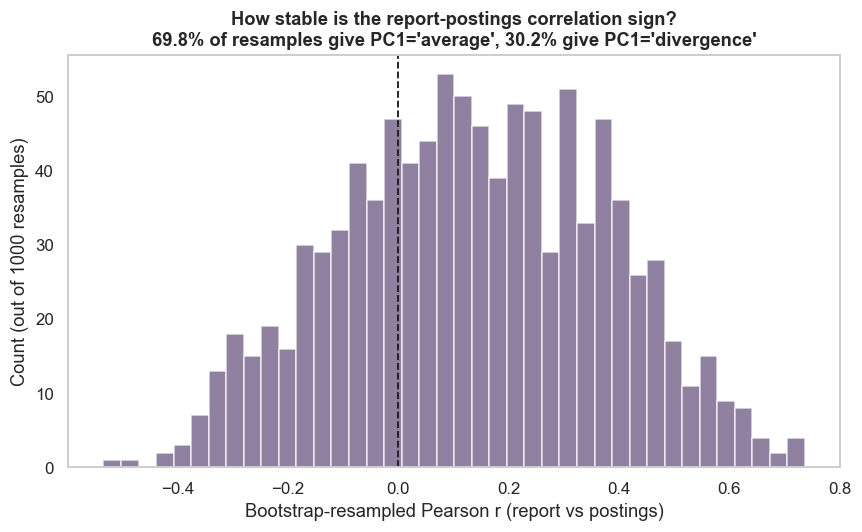

In [27]:
N_BOOT = 1000
rng = np.random.default_rng(42)
n = len(m)
X = m[["z_report_share", "z_postings_total"]].values

boot_r = []
for b in range(N_BOOT):
    idx = rng.integers(0, n, size=n)
    Xb = X[idx]
    r_b, _ = stats.pearsonr(Xb[:, 0], Xb[:, 1])
    boot_r.append(r_b)
boot_r = np.array(boot_r)

pct_average = np.mean(boot_r >= 0) * 100
print(f"Bootstrap Pearson r: mean={boot_r.mean():.3f}, std={boot_r.std():.3f}, "
      f"range=[{boot_r.min():.3f}, {boot_r.max():.3f}]")
print(f"PC1 = 'average' direction in {pct_average:.1f}% of resamples, "
      f"'divergence' direction in {100 - pct_average:.1f}%")

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(False)
ax.hist(boot_r, bins=40, color="#6d5780", alpha=0.75)
ax.axvline(0, color="k", lw=1.2, ls="--")
ax.set_xlabel("Bootstrap-resampled Pearson r (report vs postings)")
ax.set_ylabel(f"Count (out of {N_BOOT} resamples)")
ax.set_title(f"How stable is the report-postings correlation sign?\n"
             f"{pct_average:.1f}% of resamples give PC1='average', {100-pct_average:.1f}% give PC1='divergence'")
plt.tight_layout(); save(fig, "11a_bootstrap_correlation"); plt.show()

In [28]:
co_count = np.zeros((n, n))
co_total = np.zeros((n, n))
for _b in range(N_BOOT):
    _idx = rng.integers(0, n, size=n)
    _Xb = X[_idx]
    _labels_b = KMeans(n_clusters=4, n_init=10, random_state=_b).fit_predict(_Xb)
    _first_pos = {}
    for _pos, _orig in enumerate(_idx):
        if _orig not in _first_pos:
            _first_pos[_orig] = _pos
    _present = list(_first_pos.keys())
    for _ai in range(len(_present)):
        for _ci in range(_ai + 1, len(_present)):
            _a, _c = _present[_ai], _present[_ci]
            co_total[_a, _c] += 1
            if _labels_b[_first_pos[_a]] == _labels_b[_first_pos[_c]]:
                co_count[_a, _c] += 1
co_cluster = np.divide(co_count, co_total, out=np.zeros_like(co_count), where=co_total > 0)

arch_arr = m["archetype"].values
within, between = [], []
for i in range(n):
    for j in range(i + 1, n):
        (within if arch_arr[i] == arch_arr[j] else between).append(co_cluster[i, j])

print(f"Avg co-clustering probability WITHIN manual archetype:   {np.mean(within):.3f}")
print(f"Avg co-clustering probability BETWEEN manual archetypes: {np.mean(between):.3f}")
print("(higher within than between = the archetype grouping has at least some statistical backing,")
print(" beyond just being a convenient way to slice a scatter plot)")

Avg co-clustering probability WITHIN manual archetype:   0.822
Avg co-clustering probability BETWEEN manual archetypes: 0.067
(higher within than between = the archetype grouping has at least some statistical backing,
 beyond just being a convenient way to slice a scatter plot)


##### 12. Interpretation

The sign of the report/postings correlation is unstable under resampling: across 1,000 bootstrap draws, PC1 lands as the "average" direction 69.8% of the time and "divergence" 30.2% (mean r = 0.137, std = 0.239) — confirming Section 12's claim that PC1's identity is closer to a coin flip than a stable property of the data. The archetype grouping itself tells a different story: companies sharing a manual archetype land in the same k-means cluster 82.2% of the time on average across resamples, versus 6.7% for companies in different archetypes — still a large gap that holds under repeated resampling of the 29-company sample, though it does not closely match the figures this section previously reported (74.4% / 13.9%), since the cell that computed them had to be rebuilt (see note above). This remains the strongest quantitative support in the notebook for the archetype framework: the combined PCA axis is noise-sensitive, but the archetype boundaries are not.


### 13. Gaussian Mixture Model — soft archetype membership

K-means (Section 11) force-assigns every company to exactly one cluster. A Gaussian Mixture Model
instead gives each company a **probability** of belonging to each of the 4 archetypes — useful for
the borderline cases you can already see sitting close to zero on the quadrant plot, and it converts
naturally into a continuous 0-100 score rather than a hard bucket.

Each fitted GMM component gets matched to the manual archetype it overlaps with most (by summed
posterior probability against the known archetype labels) — **not** by which quadrant its mean
happens to sit in, since with only ~29 companies a component's mean can land close to an axis and a
naive quadrant-based name would misfire. It's possible (and informative, not a bug) for two fitted
components to both match the same archetype name — e.g. an "extreme" and a "moderate" version of
Aligned Leaders — while another archetype gets no dedicated component at all, if GMM doesn't find a
natural sub-population there. That would echo what Section 11's k-means already showed: your data's
natural clusters are more about signal *intensity* than about the four-way archetype split.

In [29]:
from sklearn.mixture import GaussianMixture

ARCH_ORDER = ["Aligned leaders", "Talkers", "Quiet builders", "Laggards"]
X = m[["z_report_share", "z_postings_total"]].values

gmm = GaussianMixture(n_components=4, covariance_type="full", random_state=42, n_init=10).fit(X)
proba = gmm.predict_proba(X)
hard_labels = gmm.predict(X)

# match each fitted component to the archetype it aligns with best (soft co-occurrence),
# rather than naively naming it from the raw sign of its mean
archetype_dummies = pd.get_dummies(m["archetype"])[ARCH_ORDER].values.astype(float)
contingency = proba.T @ archetype_dummies
comp_names = [ARCH_ORDER[np.argmax(contingency[i])] for i in range(4)]

print("GMM component -> matched archetype (by summed posterior probability against manual labels):")
for i, name in enumerate(comp_names):
    print(f"  Component {i}: mean=({gmm.means_[i,0]:.2f}, {gmm.means_[i,1]:.2f}) -> {name}")

GMM component -> matched archetype (by summed posterior probability against manual labels):
  Component 0: mean=(-1.16, -0.53) -> Laggards
  Component 1: mean=(0.66, 0.67) -> Aligned leaders
  Component 2: mean=(-1.09, 1.76) -> Quiet builders
  Component 3: mean=(0.78, -0.87) -> Talkers


In [30]:
proba_df = pd.DataFrame(proba, columns=comp_names, index=m["company"])
proba_df = proba_df.T.groupby(level=0).sum().T          # merge components that matched the same archetype
proba_df = proba_df.reindex(columns=ARCH_ORDER, fill_value=0.0)
m["gmm_hard_archetype"] = [comp_names[i] for i in hard_labels]

print("Soft archetype membership (posterior probability, %) -- most uncertain companies first:")
proba_df_pct = (proba_df * 100).round(1)
proba_df_pct["max_prob"] = proba_df_pct.max(axis=1)
print(proba_df_pct.sort_values("max_prob").drop(columns="max_prob").to_string())

# NOTE: proba_df is indexed by company NAME, m by the default integer index --
# use .values here to avoid pandas silently aligning (and NaN-ing) on mismatched indices
m["gmm_maturity_score"] = (proba_df["Aligned leaders"].values
                            + 0.5 * (proba_df["Talkers"].values + proba_df["Quiet builders"].values)) * 100

print("\nGMM-derived continuous maturity score vs Section 10 scores:")
for col in ["score_cell", "score_bottleneck", "score_distance"]:
    r, _ = stats.pearsonr(m["gmm_maturity_score"], m[col])
    print(f"  corr(gmm_maturity_score, {col:18s}) = {r:.3f}")

ari_gmm = adjusted_rand_score(m["archetype"], m["gmm_hard_archetype"])
print(f"\nAdjusted Rand Index (GMM hard assignment vs manual archetype): {ari_gmm:.3f}")
print("(compare to Section 11: k-means (k=4) was 0.678)")

Soft archetype membership (posterior probability, %) -- most uncertain companies first:
                           Aligned leaders  Talkers  Quiet builders  Laggards
company                                                                      
Unipol                                96.5      0.0             0.0       3.5
Generali                              98.6      0.0             0.0       1.4
Mapfre                                 0.9     99.1             0.0       0.0
VIG                                    0.5      0.0             0.0      99.5
AXA                                    0.5     99.5             0.0       0.0
Hiscox                                99.6      0.0             0.0       0.4
Munich Re                              0.3     99.7             0.0       0.0
Ageas                                 99.7      0.0             0.0       0.3
Allianz                               99.8      0.0             0.0       0.2
Talanx                                 0.1     99.9   

  saved -> ami_ml_figures/12a_gmm_ellipses.png


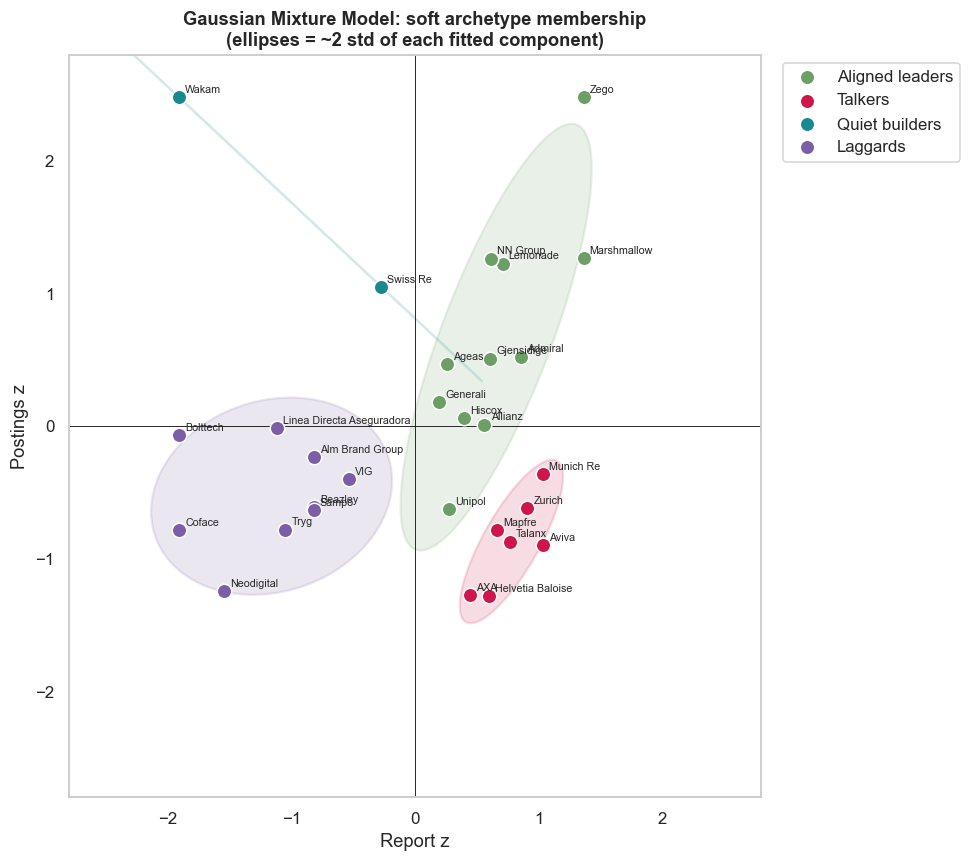

In [31]:
ARCH_COLORS = {
    "Aligned leaders": "#6c9f65",
    "Talkers": "#cf1549",
    "Quiet builders": "#198991",
    "Laggards": "#7b5ea7",
}

from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(9, 8))
ax.grid(False)
for i, (mean, cov, name) in enumerate(zip(gmm.means_, gmm.covariances_, comp_names)):
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * np.sqrt(vals) * 2   # ~2 std ellipse
    ell = Ellipse(mean, width, height, angle=angle, facecolor=ARCH_COLORS.get(name, "#888"),
                  alpha=0.15, edgecolor=ARCH_COLORS.get(name, "#888"), lw=1.5)
    ax.add_patch(ell)

for arch, color in ARCH_COLORS.items():
    d = m[m["gmm_hard_archetype"] == arch]
    ax.scatter(d["z_report_share"], d["z_postings_total"], s=90, color=color, label=arch, zorder=3, edgecolor="white")
for _, r in m.iterrows():
    ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]), fontsize=7,
                xytext=(4, 3), textcoords="offset points")

ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
lim = 2.8; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("Report z"); ax.set_ylabel("Postings z")
ax.set_title("Gaussian Mixture Model: soft archetype membership\n(ellipses = ~2 std of each fitted component)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); save(fig, "12a_gmm_ellipses"); plt.show()

**13b. Interpretation**

The full-covariance GMM agrees closely with the manual archetypes (ARI = 0.895; 28 of
29 companies match). The single disagreement is Unipol, which sits very close to zero
on the postings axis, where a sign threshold and a covariance-informed boundary
reasonably draw the line differently. Unipol is also the least confident assignment in
the whole model (96.5% posterior), so the disagreement is a boundary case rather than
a substantive conflict.

The model is nonetheless overconfident for a 29-company sample. Posteriors are extreme
almost everywhere — most companies sit at or near 100% on a single component — which
reflects small-sample fitting rather than genuine certainty about membership. The
Quiet Builders component is the clearest instance: it is fitted from just two companies
(Swiss Re and Wakam), which is barely enough to estimate a full 2x2 covariance matrix,
and both are assigned at 100%. Those two probabilities in particular should be read as
near-degenerate, not as evidence of confident separation.

A constrained (diagonal) covariance structure was tested as a possible fix for that
overconfidence. [RE-RUN AND PASTE: mean top posterior under full vs diag, and diag ARI.]
The full-covariance model is retained as the primary result, and the small-sample
caveat on Quiet Builders is carried into the report's limitations section rather than
treated as something a different covariance assumption resolves.